**Task 1: Linear Regression Task**
---


**A.   Find a dataset to build a model with**
1.   Find Data Specific to Reression Analysis
2.   Do visulalizations of the data and interpret
3.   Feature engineering determines which columns are to be dropped or which hold more weight than others - Interpretation is paramount
4.  Determine the data that has to be converted to numeric
5.   Standardize the data

**B. Using linear regression model, decision trees, and random forest (code are present) , Create and optimize a linear regression model using gradient descent using the dataset you found. With the use of the scikit-learn library**  



1.   Plot the loss curve for test data and train data.
2.   Plot a scatter plot of before and after showing where the linear line passes through the  data

**C. Save the BEST-performing model.**

**D. Create a script that uses the best model to make a prediction that will be used in task 2**




In [111]:
# Importing the relevant libraries to be used throughout the task

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection  import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Crucial for determining the best perfoming model
from sklearn.preprocessing import StandardScaler # Useful for data standardization
from sklearn.linear_model import SGDRegressor
import pickle

**A. Find a dataset to build a model with**
---

**A.1. Find Data Specific to Regression Analysis**
---
Based on my mission of  modernizing the agriculture in Rwanda especially in my local community by using technology ( Machine Learning model which help them to maximize the production, to be specific.) I looked for the data specific to Rwanda and were collected from the real local farmers in Rwanda. for more about the dataset I used and a file you can download, refer to the following link: https://figshare.com/articles/dataset/Crop_AgroVars_rawdata_Rwanda_2014-2020_csv/22574101?file=40057642

In [112]:
# Loading the dataset
df = pd.read_csv("dataset.csv")

In [113]:
# Viewing the data ( the first 20 rows)
df.head(20)

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description
0,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1311.00,Avocados,2014,2014,ha,650.00,E,Estimated value
1,QCL,Crops and livestock products,646,Rwanda,5419,Yield,1311.00,Avocados,2014,2014,hg/ha,116923.00,E,Estimated value
2,QCL,Crops and livestock products,646,Rwanda,5510,Production,1311.00,Avocados,2014,2014,tonnes,7600.00,E,Estimated value
3,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1312.00,Bananas,2014,2014,ha,409960.00,A,Official figure
4,QCL,Crops and livestock products,646,Rwanda,5419,Yield,1312.00,Bananas,2014,2014,hg/ha,25344.00,A,Official figure
5,QCL,Crops and livestock products,646,Rwanda,5510,Production,1312.00,Bananas,2014,2014,tonnes,1039020.00,A,Official figure
6,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,115.00,Barley,2014,2014,ha,0.00,M,"Missing value (data cannot exist, not applicable)"
7,QCL,Crops and livestock products,646,Rwanda,5510,Production,115.00,Barley,2014,2014,tonnes,0.00,M,"Missing value (data cannot exist, not applicable)"
8,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1701.00,"Beans, dry",2014,2014,ha,465865.00,A,Official figure
9,QCL,Crops and livestock products,646,Rwanda,5419,Yield,1701.00,"Beans, dry",2014,2014,hg/ha,8914.00,A,Official figure


In [114]:
# Understanding the dataset I have
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       1032 non-null   str    
 1   Domain            1032 non-null   str    
 2   Area Code (M49)   1032 non-null   int64  
 3   Area              1032 non-null   str    
 4   Element Code      1032 non-null   int64  
 5   Element           1032 non-null   str    
 6   Item Code (CPC)   1032 non-null   float64
 7   Item              1032 non-null   str    
 8   Year Code         1032 non-null   int64  
 9   Year              1032 non-null   int64  
 10  Unit              1032 non-null   str    
 11  Value             1032 non-null   float64
 12  Flag              1032 non-null   str    
 13  Flag Description  1032 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 113.0 KB


In [115]:
df.describe()

,Area Code (M49),Element Code,Item Code (CPC),Year Code,Year,Value
count,1032.0,1032.000000,1032.000000,1032.000000,1032.000000,1.032000e+03
mean,646.0,5413.542636,1212.909070,2017.500000,2017.500000,9.721241e+04
std,0.0,81.892173,546.154611,2.292399,2.292399,2.263906e+05
min,646.0,5312.000000,111.000000,2014.000000,2014.000000,0.000000e+00
25%,646.0,5312.000000,1234.000000,2015.750000,2015.750000,4.776250e+03
50%,646.0,5419.000000,1316.000000,2017.500000,2017.500000,2.194542e+04
75%,646.0,5510.000000,1540.000000,2019.250000,2019.250000,8.445100e+04
max,646.0,5510.000000,1970.000000,2021.000000,2021.000000,2.143866e+06


**A.1.1. Data Cleaning and Processing**
---
Looking into the dataset I have orginally, they are formatted in wide-way format which is not ideal for Machine Learning modelling. Therefore, I have to convert the dataset by taking the relevant elements and have a pivot table or a long formatted one for Machine Learning modelling.

In [116]:
# STEP 1: Create value columns (pivot values) - Process of converting the long format to wide format for ML-ready.
value_added_df = df.pivot_table(
    index=["Item", "Year"],
    columns="Element",
    values="Value",
    aggfunc="first"
).reset_index()

value_added_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Item            352 non-null    str    
 1   Year            352 non-null    int64  
 2   Area harvested  352 non-null    float64
 3   Production      352 non-null    float64
 4   Yield           328 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 13.9 KB


In [117]:
# STEP 2: Create flag columns (pivot flags) to be mergerd later
flag_added_df = df.pivot_table(
    index=["Item", "Year"],
    columns="Element",
    values="Flag Description",
    aggfunc="first"
).reset_index()

flag_added_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Item            352 non-null    str  
 1   Year            352 non-null    int64
 2   Area harvested  352 non-null    str  
 3   Production      352 non-null    str  
 4   Yield           328 non-null    str  
dtypes: int64(1), str(4)
memory usage: 13.9 KB


In [118]:
# STEP 3: Rename columns clearly ---
value_added_df.rename(columns={
    "Area harvested": "Area (ha)",
    "Yield": "Yield (hg/ha)",
    "Production": "Production (tonnes)"
}, inplace=True)

flag_added_df.rename(columns={
    "Area harvested": "Area Flag",
    "Yield": "Yield Flag",
    "Production": "Production Flag"
}, inplace=True)

In [119]:
# STEP 4: Merge values and flags, and reorder the columns for simple observation
final_df = pd.merge(value_added_df, flag_added_df, on=["Item", "Year"])
final_df.columns.name = None
final_df = final_df[
    [ "Item", "Year", "Area (ha)", "Area Flag", "Yield (hg/ha)", "Yield Flag", "Production (tonnes)", "Production Flag" ]
]

final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item                 352 non-null    str    
 1   Year                 352 non-null    int64  
 2   Area (ha)            352 non-null    float64
 3   Area Flag            352 non-null    str    
 4   Yield (hg/ha)        328 non-null    float64
 5   Yield Flag           328 non-null    str    
 6   Production (tonnes)  352 non-null    float64
 7   Production Flag      352 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 22.1 KB


In [120]:
final_df.head()

,Item,Year,Area (ha),Area Flag,Yield (hg/ha),Yield Flag,Production (tonnes),Production Flag
0,Avocados,2014,650.0,Estimated value,116923.0,Estimated value,7600.00,Estimated value
1,Avocados,2015,680.0,Estimated value,135294.0,Estimated value,9200.00,Estimated value
2,Avocados,2016,634.0,Official figure,146675.0,Official figure,9295.82,Official figure
3,Avocados,2017,950.0,Official figure,72762.0,Official figure,6912.43,Official figure
4,Avocados,2018,152.0,Official figure,566846.0,Official figure,8597.46,Official figure


**Explanation**
---
After looking at the information of the new data, I have found that some columns are missing the values so I need to take a on them

In [121]:
# Viewing the flagged items as dataset says "Missing value (data cannot exist, not applicable)" which means; those crops do not exist in Rwanda, so need to be dropped for the prediction

df_with_missing_values = final_df[final_df["Yield (hg/ha)"].isna() | final_df["Yield Flag"].isna()]
df_with_missing_values = df_with_missing_values.reset_index(drop=True)

df_with_missing_values.head()


,Item,Year,Area (ha),Area Flag,Yield (hg/ha),Yield Flag,Production (tonnes),Production Flag
0,Barley,2014,0.0,"Missing value (data cannot exist, not applicable)",NaN,NaN,0.0,"Missing value (data cannot exist, not applicable)"
1,Barley,2015,0.0,"Missing value (data cannot exist, not applicable)",NaN,NaN,0.0,"Missing value (data cannot exist, not applicable)"
2,Barley,2016,0.0,"Missing value (data cannot exist, not applicable)",NaN,NaN,0.0,"Missing value (data cannot exist, not applicable)"
3,Barley,2017,0.0,"Missing value (data cannot exist, not applicable)",NaN,NaN,0.0,"Missing value (data cannot exist, not applicable)"
4,Barley,2018,0.0,"Missing value (data cannot exist, not applicable)",NaN,NaN,0.0,"Missing value (data cannot exist, not applicable)"


**Explanation**
---
To make my model makes sense I have got to think about these missing values. Actually, those are the items which have nothing in the space of Area and that means that they are not grown in Rwanda, so it is good to drop them off and work with the crops grown in Rwanda as my mission focuses on Rwandan agriculture and my target is to predict the production of crops at given Area and other circumstances in the dataset

In [122]:
# dropping the rows which have any Missing value as flagged in the dataset from my final_df and work with the remaining ones ( the pivot table ready for ML modeling)

new_df = final_df.dropna()
new_df = new_df.reset_index(drop=True) # resetting the indexing
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item                 328 non-null    str    
 1   Year                 328 non-null    int64  
 2   Area (ha)            328 non-null    float64
 3   Area Flag            328 non-null    str    
 4   Yield (hg/ha)        328 non-null    float64
 5   Yield Flag           328 non-null    str    
 6   Production (tonnes)  328 non-null    float64
 7   Production Flag      328 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.6 KB


In [123]:
# New dataset after dropping the unnecssary observations and ready for ML modelling
new_df.head(20)

,Item,Year,Area (ha),Area Flag,Yield (hg/ha),Yield Flag,Production (tonnes),Production Flag
0,Avocados,2014,650.0,Estimated value,116923.0,Estimated value,7600.00,Estimated value
1,Avocados,2015,680.0,Estimated value,135294.0,Estimated value,9200.00,Estimated value
2,Avocados,2016,634.0,Official figure,146675.0,Official figure,9295.82,Official figure
3,Avocados,2017,950.0,Official figure,72762.0,Official figure,6912.43,Official figure
4,Avocados,2018,152.0,Official figure,566846.0,Official figure,8597.46,Official figure
5,Avocados,2019,220.0,Official figure,299517.0,Official figure,6600.51,Official figure
6,Avocados,2020,293.0,Official figure,221004.0,Official figure,6477.49,Official figure
7,Avocados,2021,286.0,Official figure,207912.0,Official figure,5950.33,Official figure
8,Bananas,2014,409960.0,Official figure,25344.0,Official figure,1039020.00,Official figure
9,Bananas,2015,403274.0,Official figure,27210.0,Official figure,1097304.00,Official figure


**A.2 Visualization and Intepretation**
---

**A.2.1. Vizualizaton 1**
---

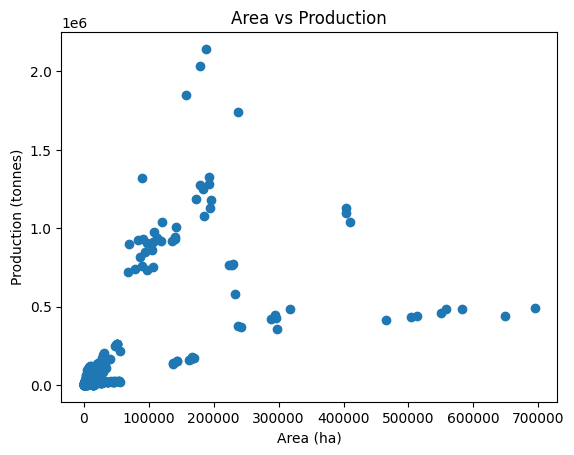

In [124]:
# Visualizing the trends between Area harvested (Area (ha)) and Production made (Production (tonnes))

plt.scatter(new_df["Area (ha)"], new_df["Production (tonnes)"])
plt.xlabel("Area (ha)")
plt.ylabel("Production (tonnes)")
plt.title("Area vs Production")
plt.show()

**A.2.1.1. Interpretation seen on the above plot of Area harvested (Area (ha)) againstProduction made (Production (tonnes))**
The scatter plot above of Area against Production, indicates the positive tendency of the relationship between the area and production pointing to the fact that the bigger are the cultivated areas the more the output is to be expected. But the data is highly scattered implying that the production is also affected by other elements that may have not been inckuded in the dataset.



**A.2.2. Visualization 2**
---

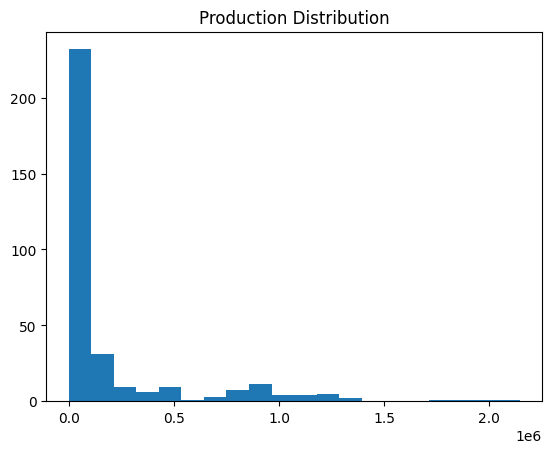

In [125]:
# Visualizing the frequency or distribution of Production with the given particular range using histogram

plt.hist(new_df["Production (tonnes)"], bins=20)
plt.title("Production Distribution")
plt.show()

**A.2.2.1. Interpretation seen on the above plot**

According to the histogram plot above, the values of production are skewed towards the right and the largest proportion of the values appeared within the lower production ranges. A limited set of cases are producing very high and this results in a long tail towards the right. It means that there is not a balanced distribution with normal production being low, with extreme outliers greatly stretching the range of the whole set of data.


**A.2.3. Visualization 3**
---

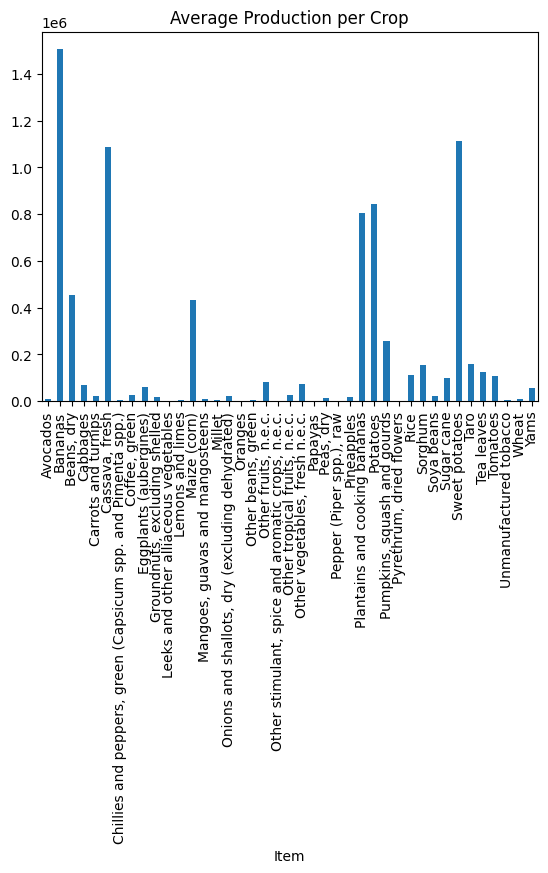

In [126]:
# Visualize the average production per crop

new_df.groupby("Item")["Production (tonnes)"].mean().plot(kind="bar")
plt.title("Average Production per Crop")
plt.show()

**A.2.3.1. Interpretation**

The bar chat plotted shows  that there is a huge difference in the average production of crops. Bananas seem to produce the highest average production with sugar cane and cassava crops coming second and third respectively. The production of most of other crops is relatively low. This implies an imbalanced distribution with a few crops contributing to the total production, with most of them having small contributions in the data set

**A.3. Numeric data conversion**
---
Looking at the dataset I have, the following are the columns that have to be converted into numeric for ML modelling;

1. Item
2. Area Flag
3. Yield Flag
4. Production Flag



In [127]:
# Converting the non-numeric data to numeric data
numerical_data = pd.get_dummies(new_df)
print(f'The shape of numerical data: {numerical_data.shape}')

The shape of numerical data: (328, 55)


In [128]:
numerical_data.head()

,Year,Area (ha),Yield (hg/ha),Production (tonnes),Item_Avocados,Item_Bananas,"Item_Beans, dry",Item_Cabbages,Item_Carrots and turnips,"Item_Cassava, fresh",...,Area Flag_Estimated value,Area Flag_Imputed value,Area Flag_Official figure,Area Flag_Unofficial figure,Yield Flag_Estimated value,Yield Flag_Official figure,Production Flag_Estimated value,Production Flag_Imputed value,Production Flag_Official figure,Production Flag_Unofficial figure
0,2014,650.0,116923.0,7600.00,True,False,False,False,False,False,...,True,False,False,False,True,False,True,False,False,False
1,2015,680.0,135294.0,9200.00,True,False,False,False,False,False,...,True,False,False,False,True,False,True,False,False,False
2,2016,634.0,146675.0,9295.82,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
3,2017,950.0,72762.0,6912.43,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
4,2018,152.0,566846.0,8597.46,True,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False


**A.4. Feature Engineering and Data Spiliting for Test and Train**
---

I chose **Production** as the target feature to make prediction on, as it is the one that matters most to the farmers and all the remaining columns =, combined together determine it. Therefore, my *y* is **Production (tonnes)** and *x* is the remaining columns except **Yield (hg/ha)** which will be dropped off with **Production (tonnes)**. **Yield (hg/ha)** wil be dropped because it depends on production and area as it was put based on the formula of Yield = Area / Production and when you observe the data, you will see that. So, it would leave the leaks if used and that could be bad for the ML model.

In [129]:
# y_predict = mx + b (Linear Regression)
x = numerical_data.drop(['Yield (hg/ha)', 'Production (tonnes)'], axis =1) # Decision made reasonably ( explained in details in the Text cell above)
y = numerical_data['Production (tonnes)']
print(f'x shape: {x.shape}\n')
print(f'y shape: {y.shape}')

x shape: (328, 53)

y shape: (328,)


In [130]:
# Data spilitting for ML-models

x_train, x_test, y_train, y_test = train_test_split(x,y , test_size = 0.2, shuffle = True, random_state=42)
print(f'Resulted X_train shape: {x_train.shape}\n')
print(f'Resulted X_test shape: {x_test.shape}\n')
print(f'Resulted y_train shape: {y_train.shape}\n')
print(f'Resulted y_test shape: {y_test.shape}')

Resulted X_train shape: (262, 53)

Resulted X_test shape: (66, 53)

Resulted y_train shape: (262,)

Resulted y_test shape: (66,)


**A.5. Data Standardization**
---
I used this on Gradient Descent as it is ideal to use scaled data with SDG (Stochastic Gradient Descent ALgorithim) and for the rest I used the non-scaled data which is very okay to use

In [131]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Checking if standardization went well, Standard deviation (std) must be closer to or equal to 1 and the mean must be equal to 0")
print(f'\nthe Mean for x_train: {np.mean(x_train_scaled)}\n')
print(f'the Mean for x_test: {np.mean(x_test_scaled)}\n')
print(f'the std for x_train: {np.std(x_train_scaled)}\n')
print(f'the std for x_test: {np.std(x_test_scaled)}\n')

Checking if standardization went well, Standard deviation (std) must be closer to or equal to 1 and the mean must be equal to 0

the Mean for x_train: 8.011898952299992e-16

the Mean for x_test: 0.0131806335557349

the std for x_train: 1.0

the std for x_test: 1.0860681466792887



**B. Using linear regression model, decision trees, and random forest (code are present) , Create and optimize a linear regression model using gradient descent using the dataset you found. With the use of the scikit-learn library**
---

In [132]:
# Initializing the Models from scikit-learn library

regression_model = LinearRegression()
tree_model = DecisionTreeRegressor()
randomForest_model = RandomForestRegressor()

In [133]:
# Linear Regression Model
model_1 = regression_model.fit(x_train,y_train)
model_1

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [134]:
# Decision Tree Regression Model
model_2 = tree_model.fit(x_train,y_train)
model_2

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [135]:
# Random Forest Regression Model
model_3 = randomForest_model.fit(x_train,y_train)
model_3

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [136]:
# LR with Gradient Descent or Stochastic Gradient Descent (SDG) Model

np.random.seed(42)
sgd = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate='constant',
    eta0=0.000001,
    random_state=42,
    warm_start=True
)

train_loss = []
test_loss = []
epochs = 100

for i in range(100):
    sgd.fit(x_train_scaled, y_train)

    train_pred = sgd.predict(x_train_scaled)
    test_pred = sgd.predict(x_test_scaled)

    train_loss.append(mean_squared_error(y_train, train_pred))
    test_loss.append(mean_squared_error(y_test, test_pred))

model_4 = sgd
model_4

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",None
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


**Making prediction on one data point in the test train data (One row of the test dataset)**
---
Using all 4 models made above. Those are;


1.   Linear Regression Model

1.   Decision Tree Regression Model
2.   Random Forest


2.   SDG



In [137]:
# Prediction made on the test dataset with Linear Regression Model
y_predict_lr = model_1.predict(x_test)
y_predict_lr[0]

np.float64(278592.9588635713)

In [138]:
# Prediction made on the test dataset with Decision Tree Regression Model
y_predict_tree = model_2.predict(x_test)
y_predict_tree[0]

np.float64(260931.23)

In [139]:
# Prediction made on the test dataset with Random Forest Regression Model
y_predict_rf = model_3.predict(x_test)
y_predict_rf[0]

np.float64(261072.0713000004)

In [140]:
# Prediction made on the test dataset with the optimized Linear Regression using Gradient Descent Model
y_predict_sgd = model_4.predict(x_test_scaled)
y_predict_sgd[0]

np.float64(-8907.24638403656)

**B.1. Plot the loss curve for test data and train data.**
---

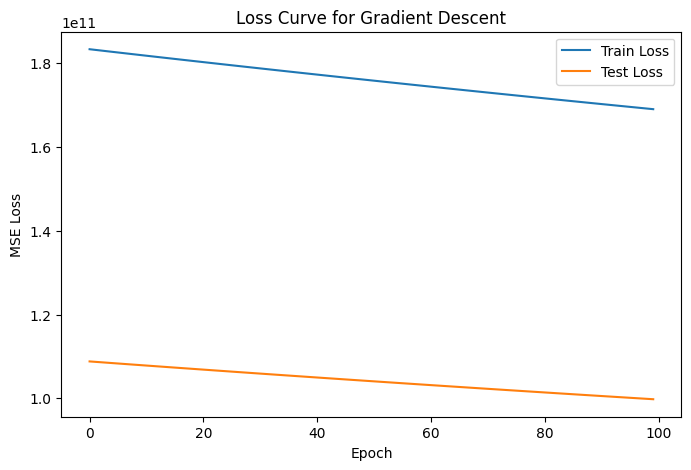

In [141]:
# Plot of loss curves

plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss Curve for Gradient Descent")
plt.legend()
plt.show()

**B.1.1 Interpretation for the  loss curve**

This loss curves plot indicate that training and testing losses both decrease gradually with the epochs, which indicates that the model is learning successfully with regard to gradient descent. The similarity in the trend of the two curves indicates that there is no overfitting in learning and thus learning is steady. Nonetheless, the loss values are high which can suggest that the model has not yet reached the saturation level and can be improved by additional tuning.

**B.2. Plot a scatter plot of before and after showing where the linear line passes through the data**
---

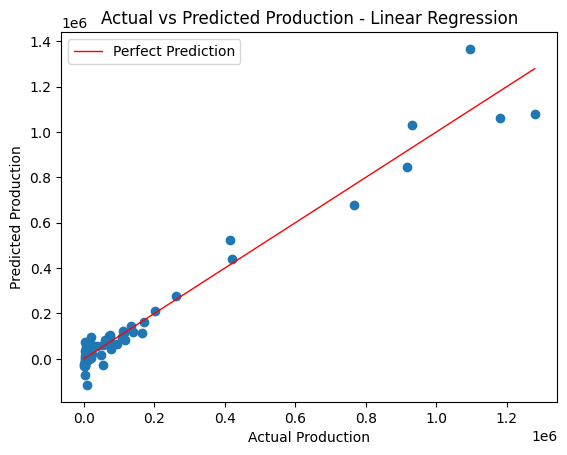

In [142]:
# Plot of Before and After

plt.scatter(y_test, y_predict_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1, label='Perfect Prediction')
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production - Linear Regression")
plt.legend()
plt.show()

**B.2.1. Interpretation**

The scatter plot is used to compare the actual and predicted values of production (Before Vs After) whose red line is used to indicate perfect predictions. The majority of the data are near the line, which means that the model does quite a good job. Nonetheless, deviations to some extent are observable, particularly in higher values, indicating errors of prediction. The general trend is well captured by the model, although not all observations can be well explained using this model.

**C. Save the BEST-performing model.**
---

In [143]:
# Comparing the MSE, MAE, RMSE to determine the best perfoming model among 4 models found above

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "SGD Regressor"],
    "MAE": [
        mean_absolute_error(y_test, y_predict_lr),
        mean_absolute_error(y_test, y_predict_tree),
        mean_absolute_error(y_test, y_predict_rf),
        mean_absolute_error(y_test, y_predict_sgd)
    ],
    "MSE": [
        mean_squared_error(y_test, y_predict_lr),
        mean_squared_error(y_test, y_predict_tree),
        mean_squared_error(y_test, y_predict_rf),
        mean_squared_error(y_test, y_predict_sgd)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_predict_lr)),
        np.sqrt(mean_squared_error(y_test, y_predict_tree)),
        np.sqrt(mean_squared_error(y_test, y_predict_rf)),
        np.sqrt(mean_squared_error(y_test, y_predict_sgd))
    ],
    "R2": [
        r2_score(y_test, y_predict_lr),
        r2_score(y_test, y_predict_tree),
        r2_score(y_test, y_predict_rf),
        r2_score(y_test, y_predict_sgd)
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,38493.063055,3.568622e+09,59737.943763,0.959319
1,Decision Tree,9942.928939,9.829228e+08,31351.600168,0.988795
2,Random Forest,12639.078303,9.813823e+08,31327.021593,0.988813
3,SGD Regressor,146325.798288,9.979058e+10,315896.475684,-0.137575


In [144]:
# Finding the row with minimum MSE to be considered the best perfoming midel

best_model_row = results.loc[results['MSE'].idxmin()]
best_model = best_model_row['Model']

print(f"Best performing model based on MSE: {best_model}")

Best performing model based on MSE: Random Forest


In [147]:
#Save the best perfoming model
best_model = model_3
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

**D. Create a script that uses the best model to make a prediction that will be used in task 2**
---
Down below is the script that takes user inputs such as Year, Area, and Item name / crop, and other inputs similar to the trained data with and predict the production using the best performing model Random Forest Regression Model.
**How it works:**
1. Load the model
2.	Collect essential inputs from the user (year, area, crop type)
3.	Transform categorical inputs into one-hot encoded features
4.	Populate all other required features to match the model’s training data
5.	Return a single prediction from the model


In [148]:
# Load the saved Random Forest model as was the best performing model
with open("best_model.pkl", "rb") as f:
    best_model = pickle.load(f)

# List of all item columns (one-hot) in order as they are in the dataset
ITEM_COLUMNS = [
    "Item_Avocados","Item_Bananas","Item_Beans, dry","Item_Cabbages",
    "Item_Carrots and turnips","Item_Cassava, fresh",
    "Item_Chillies and peppers, green (Capsicum spp. and Pimenta spp.)",
    "Item_Coffee, green","Item_Eggplants (aubergines)","Item_Groundnuts, excluding shelled",
    "Item_Leeks and other alliaceous vegetables","Item_Lemons and limes","Item_Maize (corn)",
    "Item_Mangoes, guavas and mangosteens","Item_Millet",
    "Item_Onions and shallots, dry (excluding dehydrated)","Item_Oranges","Item_Other beans, green",
    "Item_Other fruits, n.e.c.","Item_Other stimulant, spice and aromatic crops, n.e.c.",
    "Item_Other tropical fruits, n.e.c.","Item_Other vegetables, fresh n.e.c.",
    "Item_Papayas","Item_Peas, dry","Item_Pepper (Piper spp.), raw","Item_Pineapples",
    "Item_Plantains and cooking bananas","Item_Potatoes","Item_Pumpkins, squash and gourds",
    "Item_Pyrethrum, dried flowers","Item_Rice","Item_Sorghum","Item_Soya beans",
    "Item_Sugar cane","Item_Sweet potatoes","Item_Taro","Item_Tea leaves","Item_Tomatoes",
    "Item_Unmanufactured tobacco","Item_Wheat","Item_Yams"
]

# List of flag columns again in order
FLAG_COLUMNS = [
    "Area Flag_Estimated value","Area Flag_Imputed value","Area Flag_Official figure","Area Flag_Unofficial figure",
    "Yield Flag_Estimated value","Yield Flag_Official figure",
    "Production Flag_Estimated value","Production Flag_Imputed value","Production Flag_Official figure","Production Flag_Unofficial figure"
]

# function for Prediction
def predict_production(year: int, area_ha: float, item_name: str) -> float:
    """
    Predict production using the saved best performing model (Random Forest Regression Model).

    Parameters:
    - year (int): Year of the record
    - area_ha (float): Area harvested in hectares
    - item_name (str): Name of the crop, must match one of the ITEM_COLUMNS

    Returns:
    - float: Predicted Production (tonnes)
    """

    # Build the one-hot item dictionary
    item_dict = {col: False for col in ITEM_COLUMNS}
    # Make the selected item True
    matching_cols = [col for col in ITEM_COLUMNS if item_name.lower() in col.lower()]
    if not matching_cols:
        raise ValueError(f"Item '{item_name}' not recognized. Check spelling!")
    item_dict[matching_cols[0]] = True

    # Set flag columns to False by default ( Not crucuial for the prediction)
    flag_dict = {col: False for col in FLAG_COLUMNS}

    # Build the full DataFrame
    input_data = pd.DataFrame([{
        "Year": year,
        "Area (ha)": area_ha,
        **item_dict,
        **flag_dict
    }])

    # Predict the user input
    predicted_value = best_model.predict(input_data)

    return predicted_value[0]

# Usage example in action
if __name__ == "__main__":
    year = int(input("Enter Year (int): "))
    area = float(input("Enter Area (ha): "))
    item = input("Enter crop/item name (e.g., Maize, Beans, dry): ")

    prediction = predict_production(year, area, item)
    print(f"\nPredicted Production (tonnes): {prediction}")


Predicted Production (tonnes): 7514.757599999996
